## Import libraries

In [ ]:
import os
import sys

sys.path.insert(0, os.path.abspath('..'))  # Add parent folder

from utils import load_metabric_data

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from watermark import watermark

warnings.simplefilter(action="ignore", category=FutureWarning)

print(watermark())

Last updated: 2026-04-16T23:50:10.875167+03:00

Python implementation: CPython
Python version       : 3.12.0
IPython version      : 9.12.0

Compiler    : Clang 14.0.6 
OS          : Darwin
Release     : 25.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit



In [ ]:
print(watermark(packages="numpy,pandas,seaborn,shap,sklearn"))

numpy  : 2.4.3
pandas : 3.0.1
seaborn: 0.13.2
shap   : 0.51.0
sklearn: 1.8.0



In [ ]:
RANDOM_STATE=42

## Load Data

In [ ]:
# local load
#df = pd.read_csv('../data/METABRIC_RNA_Mutation.csv', low_memory=False)

# or directly from kaggle
df = load_metabric_data()

df.shape

Fetching METABRIC dataset from Kaggle...


(1904, 693)

In [ ]:
df['pam50_+_claudin-low_subtype'].value_counts()

pam50_+_claudin-low_subtype
LumA           679
LumB           461
Her2           220
claudin-low    199
Basal          199
Normal         140
NC               6
Name: count, dtype: int64

In [ ]:
# We isolate only the patients classified as Luminal A ('LumA').
# This guarantees our model only looks at clinical variance within this "low-risk" group.

df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()

In [ ]:
df_LumA.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
10,36,85.49,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
13,46,83.02,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
23,68,51.01,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
29,97,78.19,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


## Data insights

In [ ]:
# We want to predict purely breast cancer mortality (1) vs surviving/other death (0).

df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0
)

df_LumA['target_mortality'].value_counts()

target_mortality
0    533
1    146
Name: count, dtype: int64

In [ ]:
total_luma = len(df_LumA)
died_luma = len(df_LumA[df_LumA['target_mortality'] == 1])
lived_luma = len(df_LumA[df_LumA['target_mortality'] == 0])
mortality_rate = (died_luma / total_luma) * 100

print("Survival Stats:\n------")
print(f"Subset of patients assigned with Luminal A: {total_luma}")
print(f"Patients who LIVED (Expected): {lived_luma}")
print(f"Patients who DIED (The Discordant Group): {died_luma}")
print(f"Discordance Rate: {mortality_rate:.1f}%\n------")

Survival Stats:
------
Subset of patients assigned with Luminal A: 679
Patients who LIVED (Expected): 533
Patients who DIED (The Discordant Group): 146
Discordance Rate: 21.5%
------


In [ ]:
# Drop columns that would cause data leakage (like survival_months) or target variables
leakage_cols = ['patient_id', 'overall_survival_months',
                 'overall_survival', 'death_from_cancer', 'target_mortality']

# Automatically select all numeric columns from the isolated Luminal A dataset
numeric_cols = df_LumA.select_dtypes(include=['number']).columns.tolist()

# Filter out the leakage columns
features = [col for col in numeric_cols if col not in leakage_cols]

X = df_LumA[features]
y = df_LumA['target_mortality']

print(f"Shape of newly created dataset: {X.shape}")

Shape of newly created dataset: (679, 500)


In [ ]:
# Subset of 'Luminal A' into the two outcomes

LumA_died = df_LumA[df_LumA['target_mortality'] == 1]
LumA_lived = df_LumA[df_LumA['target_mortality'] == 0]

In [ ]:
# The features we want to compare

features_to_compare = [
    'nottingham_prognostic_index',
    'tumor_size',
    'neoplasm_histologic_grade',
    'lymph_nodes_examined_positive'
]

for feature in features_to_compare:

    mean_died = LumA_died[feature].mean()
    mean_lived = LumA_lived[feature].mean()
    std_died = LumA_died[feature].std()
    std_lived = LumA_lived[feature].std()
    
    print(f"Examined feature: {feature} (mean ± std):")
    print(f"  -> Patients who DIED : {mean_died:.2f} ± {std_died:.2f}")
    print(f"  -> Patients who LIVED: {mean_lived:.2f} ± {std_lived:.2f}")
    print("-" * 40)

Examined feature: nottingham_prognostic_index (mean ± std):
  -> Patients who DIED : 4.01 ± 1.19
  -> Patients who LIVED: 3.49 ± 1.05
----------------------------------------
Examined feature: tumor_size (mean ± std):
  -> Patients who DIED : 28.17 ± 15.97
  -> Patients who LIVED: 22.64 ± 10.23
----------------------------------------
Examined feature: neoplasm_histologic_grade (mean ± std):
  -> Patients who DIED : 2.29 ± 0.61
  -> Patients who LIVED: 2.02 ± 0.66
----------------------------------------
Examined feature: lymph_nodes_examined_positive (mean ± std):
  -> Patients who DIED : 2.77 ± 4.74
  -> Patients who LIVED: 1.15 ± 2.48
----------------------------------------


## Data modeling (specific train/test split)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

### Pre-processing steps

In [ ]:
# we impute missing numeric values with the median of that specific feature.

missing_values = X.isnull().sum()

columns_to_impute = missing_values[missing_values > 0].index.tolist()
print(missing_values[missing_values > 0].to_string())

total_imputed = missing_values.sum()
print(f"\n\nTotal imputed data points: {total_imputed} (out of {X.shape[0] * X.shape[1]} total points)")

# detect numerical columns

numeric_columns = X.select_dtypes(include="number").columns



numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_columns)
    ],
    remainder="passthrough"
)

preprocessor.set_output(transform="pandas")
preprocessor.verbose_feature_names_out = False

neoplasm_histologic_grade     31
mutation_count                 7
tumor_size                     1
tumor_stage                  159


Total imputed data points: 198 (out of 339500 total points)


In [ ]:
assert len(numeric_columns) == X.shape[1]

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [ ]:
scaler = (
    preprocessor
        .named_transformers_["num"]
        .named_steps["scaler"]
)

means = scaler.mean_
stds = scaler.scale_

print("Scaler means:")
print(means[0:3])

print("Scaler standard deviations:")
print(stds[0:3])

Scaler means:
[63.11882136  0.07918969  2.57642726]
Scaler standard deviations:
[12.50139226  0.27003459  1.16942185]


In [ ]:
imputer = (
    preprocessor
        .named_transformers_["num"]
        .named_steps["imputer"]
)

medians = imputer.statistics_

missing_mask = X_train[numeric_columns].isna().any(axis=0).values

missing_columns = np.array(numeric_columns)[missing_mask]
missing_medians = medians[missing_mask]
print("Median per numeric column with missing values:")


median_df = pd.DataFrame({
    "column": missing_columns,
    "median": missing_medians
})

print(median_df)

Median per numeric column with missing values:
                      column  median
0  neoplasm_histologic_grade     2.0
1             mutation_count     5.0
2                 tumor_size    20.0
3                tumor_stage     2.0


In [ ]:
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, random_state=42),
        {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'class_weight': [None, 'balanced']}
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'class_weight': [None, 'balanced']}
    )
}

In [21]:
%%time

best_models = {}
best_auc = 0
winning_model_name = ""
winning_model = None

for name, (model, params) in models.items():
    grid = GridSearchCV(
        model,
        params,
        cv=5,
        scoring={
            "balanced_accuracy": "balanced_accuracy",
            "roc_auc": "roc_auc",
        },
        refit="roc_auc",
        n_jobs=-1
    )
    grid.fit(X_train_processed, y_train)

    test_proba = grid.predict_proba(X_test_processed)[:, 1]
    test_pred = grid.predict(X_test_processed)

    test_auc = roc_auc_score(y_test, test_proba)
    test_bal_acc = balanced_accuracy_score(y_test, test_pred)


    cv_auc = grid.best_score_
    cv_bal_acc = grid.cv_results_["mean_test_balanced_accuracy"][grid.best_index_]

    best_models[name] = grid.best_estimator_
    print(
        f"{name:<20} | CV AUC = {cv_auc:.3f} | CV Bal Acc = {cv_bal_acc:.3f} | "
        f"Test AUC = {test_auc:.3f} | Test Bal Acc = {test_bal_acc:.3f}"
    )

    if test_auc > best_auc:
        best_auc, best_bal_acc = test_auc, test_bal_acc
        winning_model_name = name
        winning_model = grid.best_estimator_


print(f"\n\n🏆 WINNING MODEL: {winning_model_name} (Test AUC: {best_auc:.3f}, Test Bal Acc: {best_bal_acc:.3f})")

Logistic Regression  | CV AUC = 0.694 | CV Bal Acc = 0.614 | Test AUC = 0.628 | Test Bal Acc = 0.587
Random Forest        | CV AUC = 0.679 | CV Bal Acc = 0.557 | Test AUC = 0.682 | Test Bal Acc = 0.615
SVM                  | CV AUC = 0.691 | CV Bal Acc = 0.553 | Test AUC = 0.655 | Test Bal Acc = 0.574


🏆 WINNING MODEL: Random Forest (Test AUC: 0.682, Test Bal Acc: 0.615)
CPU times: user 715 ms, sys: 144 ms, total: 859 ms
Wall time: 10.8 s


In [ ]:
assert isinstance(winning_model, sklearn.base.BaseEstimator), "winning_model should be an instance of a scikit-learn estimator"

## Performance plots

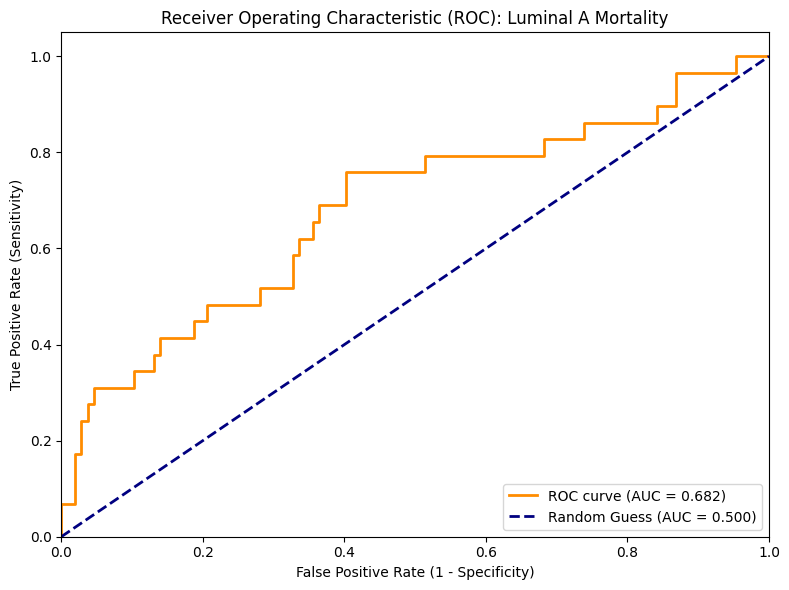

In [ ]:
if not hasattr(winning_model, "predict_proba"):
    raise AttributeError("winning_model has no predict_proba; ensure it's a classifier with predict_proba()")
test_proba = winning_model.predict_proba(X_test_processed)[:, 1]

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {best_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC): Luminal A Mortality')
plt.legend(loc="lower right")
plt.tight_layout()
#plt.savefig("ROC_Curve_LumA.pdf", format='pdf', dpi=300)
plt.show()

In [ ]:
# Threshold Moving & Calibration Plot

test_proba = winning_model.predict_proba(X_test_processed)[:, 1]
y_pred = winning_model.predict(X_test_processed)

fpr, tpr, thresholds = roc_curve(y_test, test_proba)

# Youden's J (J = TPR - FPR)
youden_j = tpr - fpr
best_threshold_index = np.argmax(youden_j)
best_thresh = thresholds[best_threshold_index]

print("Default threshold equals to 0.500")
print(f"The optimal threshold tuned based on ROC curve equals to  {best_thresh:.3f}\n")

y_pred_custom = (test_proba >= best_thresh).astype(int)

print(f"Classification Report (with optimal Threshold = {best_thresh:.3f}):")
print(classification_report(y_test, y_pred_custom))

test_auc_custom = roc_auc_score(y_test, y_pred_custom)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_custom)

print(f"\n\n🏆 Threshold tuned model: Test AUC: {test_auc_custom:.3f}, Test Bal Acc: {test_bal_acc:.3f}")

Default threshold equals to 0.500
The optimal threshold tuned based on ROC curve equals to  0.429

Classification Report (with optimal Threshold = 0.429):
              precision    recall  f1-score   support

           0       0.90      0.60      0.72       107
           1       0.34      0.76      0.47        29

    accuracy                           0.63       136
   macro avg       0.62      0.68      0.59       136
weighted avg       0.78      0.63      0.67       136



🏆 Threshold tuned model: Test AUC: 0.678, Test Bal Acc: 0.678


### Confusion matrix with default threshold

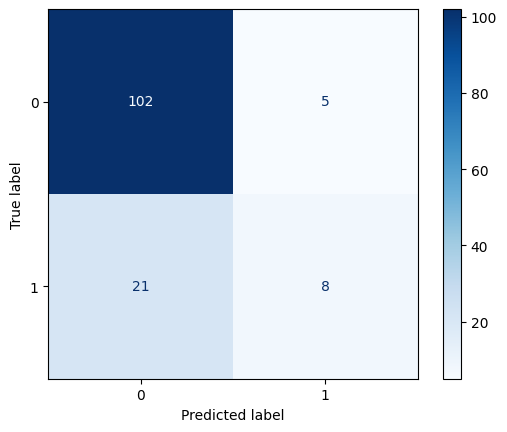

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.show()

### Confusion matrix with tuned threshold

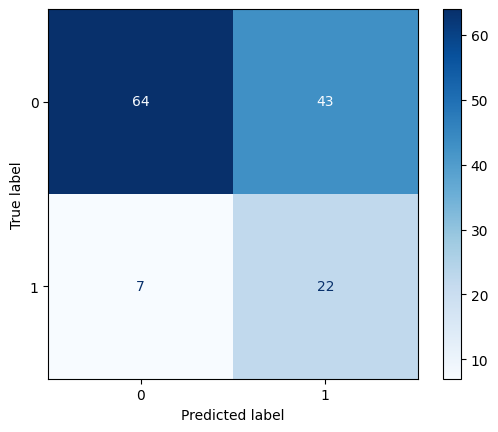

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, cmap="Blues")
plt.show()

### Calibration curve

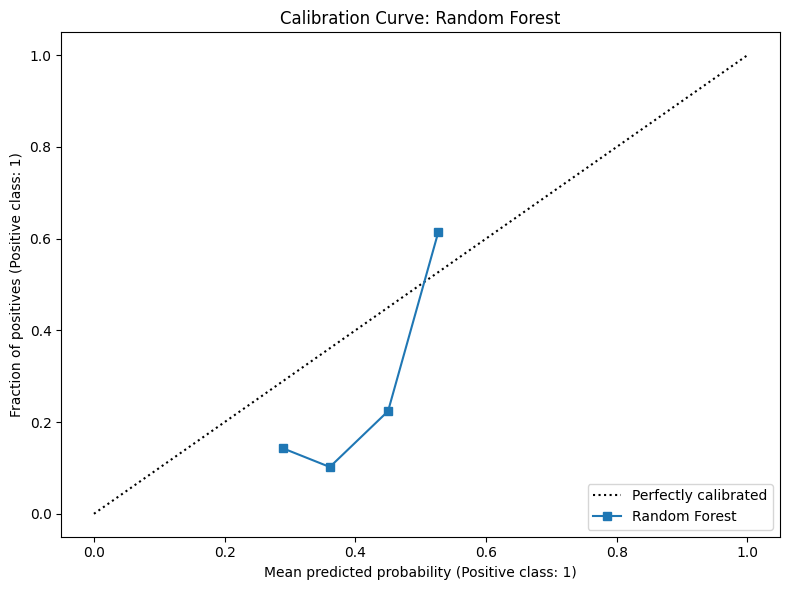

In [ ]:
plt.figure(figsize=(8, 6))
CalibrationDisplay.from_estimator(
    winning_model,
    X_test_processed,
    y_test,
    n_bins=10,
    name=winning_model_name,
    ax=plt.gca()
)
plt.title(f"Calibration Curve: {winning_model_name}")
plt.tight_layout()
#plt.savefig("Calibration_Curve_LumA.pdf", format='pdf', dpi=300)
plt.show()

### Incremental Feature Gain Analysis (Forward Feature Evaluation)

In [ ]:
# Extract and sort the feature importances from the winning Random Forest
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': winning_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top_5_features = feature_importances['Feature'].head(5).tolist()

In [ ]:
# CLINICAL VALUE ADDITION TABLE (Baseline Assumption: Genomic PAM50 Status (Luminal A) = 'Low Risk)
incremental_features = []
previous_auc = 0.500
auc_scores = [previous_auc]
gain_scores = [0.0]
feature_labels = ['PAM50\n(Baseline)']

# Loop through the top 5 features, adding them one by one
for i, feature in enumerate(top_5_features):
    incremental_features.append(feature)

    X_train_subset = X_train_processed[incremental_features]
    X_test_subset = X_test_processed[incremental_features]

    mini_rf = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
    mini_rf.fit(X_train_subset, y_train)

    mini_proba = mini_rf.predict_proba(X_test_subset)[:, 1]
    current_auc = roc_auc_score(y_test, mini_proba)
    gain = current_auc - previous_auc

    # Store for plotting
    auc_scores.append(current_auc)
    gain_scores.append(gain)
    feature_labels.append(f"+ {feature}")

    previous_auc = current_auc

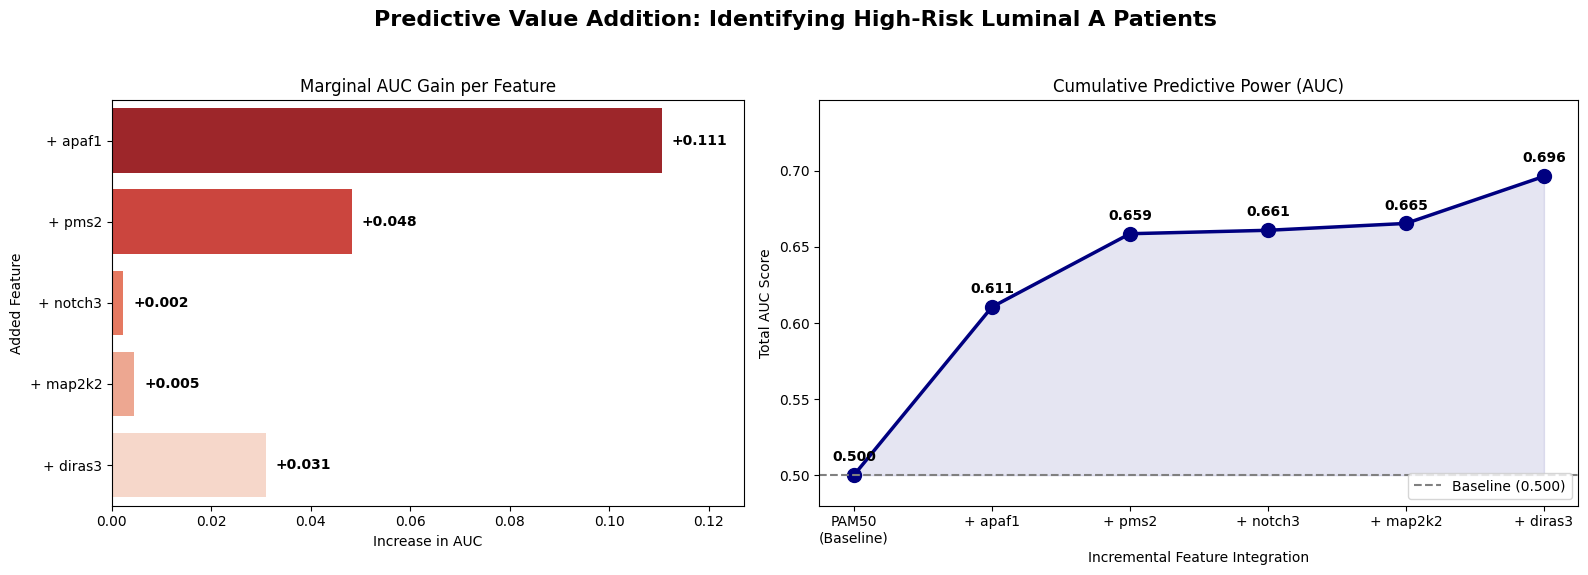

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle("Predictive Value Addition: Identifying High-Risk Luminal A Patients", fontsize=16, fontweight='bold')

# Horizontal Bar Chart of Marginal Gains
sns.barplot(x=gain_scores[1:], y=feature_labels[1:], ax=ax1, palette="Reds_r")

max_gain = max(gain_scores[1:])
padding = max_gain * 0.15  # 15% breathing room

ax1.set_xlim(0, max_gain + padding)


ax1.set_title("Marginal AUC Gain per Feature", fontsize=12)
ax1.set_xlabel("Increase in AUC")
ax1.set_ylabel("Added Feature")
for i, v in enumerate(gain_scores[1:]):
    ax1.text(v + 0.002, i, f"+{v:.3f}", color='black', va='center', fontweight='bold')

# Line Plot of Cumulative AUC
ax2.plot(feature_labels, auc_scores, marker='o', markersize=10, linestyle='-', color='navy', linewidth=2.5)
ax2.fill_between(feature_labels, 0.500, auc_scores, color='navy', alpha=0.1)
ax2.axhline(y=0.500, color='gray', linestyle='--', label='Baseline (0.500)')
ax2.set_title("Cumulative Predictive Power (AUC)", fontsize=12)
ax2.set_xlabel("Incremental Feature Integration")
ax2.set_ylabel("Total AUC Score")
ax2.set_ylim(0.48, max(auc_scores) + 0.05)
ax2.legend(loc="lower right")

# Annotate the line chart points
for i, txt in enumerate(auc_scores):
    ax2.annotate(f"{txt:.3f}", (feature_labels[i], auc_scores[i]),
                 textcoords="offset points", xytext=(0, 10), ha='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#plt.savefig("Clinical_Value_Addition_Dashboard.pdf", format='pdf', dpi=300)
plt.show()

## Explainable AI (Shapley values)

In [ ]:
# TreeExplainer calculates the exact marginal contribution of every clinical feature.

explainer = shap.TreeExplainer(winning_model)
shap_values = explainer.shap_values(X_test_processed)
shap_values.shape

(136, 500, 2)

In [ ]:
# For binary classification in Random Forest, shap_values is a list.
# Index 1 is the explanation for the positive class (target_mortality = 1).

shap_values_disease_death = shap_values[1] if isinstance(shap_values, list) else shap_values
shap_values_disease_death.shape

(136, 500, 2)

In [ ]:
shap_values_death = shap_values[:,:,1]
shap_values_death.shape

(136, 500)

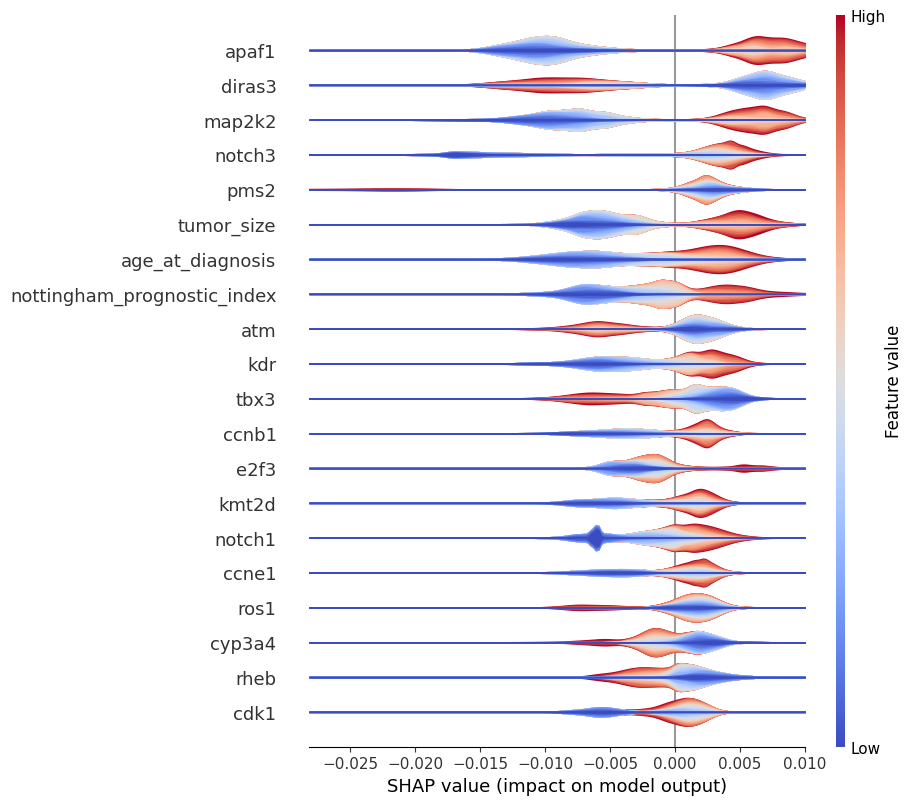

In [ ]:
# Layered violin plot explanation: https://shap.readthedocs.io/en/stable/example_notebooks/api_examples/plots/violin.html

shap.plots.violin(shap_values_death, features=X_test_processed,
                   feature_names=features, plot_type="layered_violin")

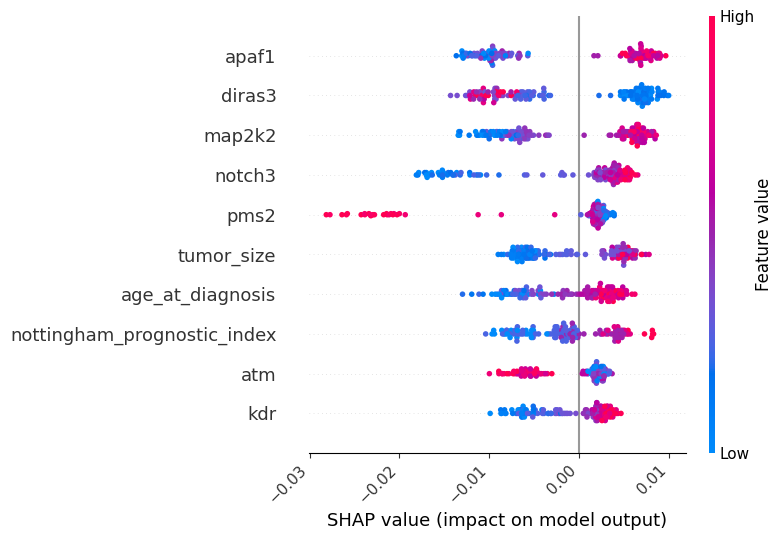

In [ ]:
"""
Plot the top 10 most important features
Each dot is a patient.
Red dots = high feature value (e.g., high NPI). Blue dots = low feature value.
Dots pushed to the right mean that feature increased the risk of death.
"""

shap.summary_plot(shap_values_death,
                    X_test_processed,
                    feature_names=features, 
                    max_display=10,
                    show=False)


plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Cross-val-predict

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1_000, random_state=42),
        {
            "classifier__C": [0.01, 0.1, 1, 10],
            "classifier__class_weight": [None, "balanced"]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "classifier__n_estimators": [50, 100, 200],
            "classifier__max_depth": [3, 5, 7],
            "classifier__class_weight": [None, "balanced"]
        }
    ),
    "SVM": (
        SVC(probability=True, random_state=42),
        {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"],
            "classifier__class_weight": [None, "balanced"]
        }
    )
}


results = {}
cv_results_all = {}

for model_name, (estimator, param_grid) in models.items():
    print(f"\nRunning nested CV for {model_name}")

    # Build pipeline
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("classifier", estimator)
        ]
    )

    y_pred = np.zeros(len(y))
    best_params_per_model = []
    cv_results_all_per_model = []


    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=inner_cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)


        # inside the outer-CV loop, after grid.fit(...)
        cv_results = pd.DataFrame(grid.cv_results_)
        cv_results["model"] = model_name
        cv_results["outer_fold"] = fold

        cv_results_all_per_model.append(cv_results)


        # Store predictions
        y_pred[test_idx] = grid.predict(X_test)

        # Store best parameters
        best_params_per_model.append({
            "model": model_name,
            "fold": fold,
            **grid.best_params_
        })

    # out of inner loop
    results[model_name] = {
        #"y_pred": y_pred,
        "best_params": pd.DataFrame(best_params_per_model)
    }

    cv_results_all[model_name] = cv_results_all_per_model


Running nested CV for Logistic Regression

Running nested CV for Random Forest

Running nested CV for SVM


In [ ]:
results['SVM']

{'best_params':   model  fold  classifier__C classifier__class_weight classifier__kernel
 0   SVM     0            0.1                      NaN                rbf
 1   SVM     1            0.1                 balanced                rbf
 2   SVM     2            1.0                      NaN                rbf
 3   SVM     3            1.0                 balanced                rbf
 4   SVM     4            1.0                      NaN                rbf}

In [ ]:
cv_results_all.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'SVM'])

In [ ]:
cv_results_all['SVM'][0]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__class_weight,param_classifier__kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,model,outer_fold
0,0.098952,0.004714,0.011097,0.001991,0.1,NaN,linear,"{'classifier__C': 0.1, 'classifier__class_weig...",0.597147,0.620621,0.609787,0.609185,0.009593,5,SVM,0
1,0.130730,0.003759,0.024451,0.004421,0.1,NaN,rbf,"{'classifier__C': 0.1, 'classifier__class_weig...",0.608342,0.667028,0.576562,0.617311,0.037473,1,SVM,0
2,0.105147,0.003683,0.014646,0.007989,0.1,balanced,linear,"{'classifier__C': 0.1, 'classifier__class_weig...",0.597147,0.620621,0.609787,0.609185,0.009593,5,SVM,0
3,0.141592,0.015881,0.027590,0.004542,0.1,balanced,rbf,"{'classifier__C': 0.1, 'classifier__class_weig...",0.574576,0.631997,0.609787,0.605453,0.023642,11,SVM,0
4,0.120591,0.010982,0.016112,0.000925,1.0,NaN,linear,"{'classifier__C': 1, 'classifier__class_weight...",0.597147,0.620621,0.609787,0.609185,0.009593,5,SVM,0
5,0.132802,0.012084,0.022653,0.005956,1.0,NaN,rbf,"{'classifier__C': 1, 'classifier__class_weight...",0.608704,0.666667,0.575840,0.617070,0.037549,2,SVM,0
6,0.109759,0.009371,0.014230,0.007687,1.0,balanced,linear,"{'classifier__C': 1, 'classifier__class_weight...",0.597147,0.620621,0.609787,0.609185,0.009593,5,SVM,0
7,0.132722,0.017620,0.021909,0.003854,1.0,balanced,rbf,"{'classifier__C': 1, 'classifier__class_weight...",0.591008,0.631094,0.593174,0.605092,0.018408,12,SVM,0
8,0.103155,0.018398,0.013636,0.002395,10.0,NaN,linear,"{'classifier__C': 10, 'classifier__class_weigh...",0.597147,0.620621,0.609787,0.609185,0.009593,5,SVM,0
9,0.133960,0.006953,0.018003,0.002527,10.0,NaN,rbf,"{'classifier__C': 10, 'classifier__class_weigh...",0.609426,0.652582,0.583062,0.615023,0.028656,3,SVM,0


In [ ]:
cv_results = pd.DataFrame()

for model_name, _ in cv_results_all.items():
    for fold_results in cv_results_all[model_name]:
        cv_results = pd.concat([cv_results, fold_results], ignore_index=True)

cv_results.shape

(190, 18)

In [ ]:
cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__class_weight,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,model,outer_fold,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__kernel
0,0.086386,0.007149,0.020058,0.000520,0.01,NaN,"{'classifier__C': 0.01, 'classifier__class_wei...",0.593536,0.635428,0.598411,0.609125,0.018705,4,Logistic Regression,0,NaN,NaN,NaN
1,0.097864,0.002721,0.034101,0.007739,0.01,balanced,"{'classifier__C': 0.01, 'classifier__class_wei...",0.594619,0.629289,0.600036,0.607981,0.015228,5,Logistic Regression,0,NaN,NaN,NaN
2,0.125074,0.027810,0.034540,0.015813,0.10,NaN,"{'classifier__C': 0.1, 'classifier__class_weig...",0.587938,0.628205,0.602384,0.606176,0.016656,7,Logistic Regression,0,NaN,NaN,NaN
3,0.095421,0.008010,0.036548,0.014440,0.10,balanced,"{'classifier__C': 0.1, 'classifier__class_weig...",0.588118,0.628025,0.602203,0.606115,0.016525,8,Logistic Regression,0,NaN,NaN,NaN
4,0.086082,0.007329,0.028891,0.027244,1.00,NaN,"{'classifier__C': 1, 'classifier__class_weight...",0.594258,0.626761,0.606717,0.609245,0.013389,3,Logistic Regression,0,NaN,NaN,NaN


In [ ]:
param_cols = [c for c in cv_results.columns if c.startswith("param_")]
param_cols

['param_classifier__C',
 'param_classifier__class_weight',
 'param_classifier__max_depth',
 'param_classifier__n_estimators',
 'param_classifier__kernel']

In [ ]:
config_summary = (
    cv_results
    .groupby(["model"]+ param_cols, dropna=False)
    .agg(
        mean_auc=("mean_test_score", "mean"),
        std_auc=("mean_test_score", "std"),
        times_best=("rank_test_score", lambda x: (x == 1).sum())
    )
    .reset_index()
    .sort_values("mean_auc", ascending=False)
)

In [ ]:
config_summary.head()

,model,param_classifier__C,param_classifier__class_weight,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__kernel,mean_auc,std_auc,times_best
33,SVM,1.0,NaN,NaN,NaN,rbf,0.677177,0.038996,2
29,SVM,0.1,NaN,NaN,NaN,rbf,0.677105,0.038761,1
31,SVM,1.0,balanced,NaN,NaN,rbf,0.673586,0.042270,1
19,Random Forest,NaN,NaN,3.0,200.0,NaN,0.670870,0.027723,2
35,SVM,10.0,balanced,NaN,NaN,rbf,0.670459,0.039522,0


In [ ]:
best_config = config_summary.iloc[0]
best_config

model                                  SVM
param_classifier__C                    1.0
param_classifier__class_weight         NaN
param_classifier__max_depth            NaN
param_classifier__n_estimators         NaN
param_classifier__kernel               rbf
mean_auc                          0.677177
std_auc                           0.038996
times_best                               2
Name: 33, dtype: object

In [ ]:
stable_configs = config_summary.query("std_auc < 0.05")
best_config = stable_configs.iloc[0]
best_config

model                                  SVM
param_classifier__C                    1.0
param_classifier__class_weight         NaN
param_classifier__max_depth            NaN
param_classifier__n_estimators         NaN
param_classifier__kernel               rbf
mean_auc                          0.677177
std_auc                           0.038996
times_best                               2
Name: 33, dtype: object

In [ ]:
best_model_name = best_config["model"]
best_estimator, _ = models[best_model_name]

final_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", best_estimator)
    ]
)

# Extract only the pipeline parameters
final_params = {
    k.replace("param_", ""): v
    for k, v in best_config.items()
    if k.startswith("param_") and pd.notna(v)
}

final_pipeline.set_params(**final_params)

if model_name == 'SVM':
    if 'classifier__class_weight' not in final_params:
        final_pipeline.set_params(classifier__class_weight=None)
final_pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

### Results in the training subset

[[533   0]
 [ 69  77]]


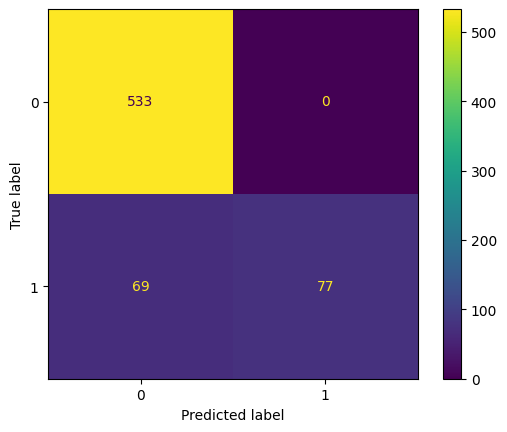

In [ ]:
cm = confusion_matrix(y, final_pipeline.predict(X))
print(cm)

ConfusionMatrixDisplay(cm).plot();

### Results per distinct models

In [ ]:
results.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'SVM'])

In [ ]:
results["Logistic Regression"]["best_params"]

,model,fold,classifier__C,classifier__class_weight
0,Logistic Regression,0,1.00,balanced
1,Logistic Regression,1,0.01,NaN
2,Logistic Regression,2,0.01,NaN
3,Logistic Regression,3,0.01,NaN
4,Logistic Regression,4,0.01,NaN


In [ ]:
# from sklearn.metrics import roc_auc_score

# model_auc = []

# for model_name, res in cv_results.items():
#     auc = roc_auc_score(y, res["y_pred"])
#     model_auc.append({"model": model_name, "outer_auc": auc})

# model_ranking = (
#     pd.DataFrame(model_auc)
#     .sort_values("outer_auc", ascending=False)
# )

In [ ]:
config_summary

,model,param_classifier__C,param_classifier__class_weight,param_classifier__max_depth,param_classifier__n_estimators,param_classifier__kernel,mean_auc,std_auc,times_best
33,SVM,1.00,NaN,NaN,NaN,rbf,0.677177,0.038996,2
29,SVM,0.10,NaN,NaN,NaN,rbf,0.677105,0.038761,1
31,SVM,1.00,balanced,NaN,NaN,rbf,0.673586,0.042270,1
19,Random Forest,NaN,NaN,3.0,200.0,NaN,0.670870,0.027723,2
35,SVM,10.00,balanced,NaN,NaN,rbf,0.670459,0.039522,0
37,SVM,10.00,NaN,NaN,NaN,rbf,0.670459,0.039522,0
1,Logistic Regression,0.01,NaN,NaN,NaN,NaN,0.667447,0.045386,4
16,Random Forest,NaN,balanced,7.0,200.0,NaN,0.664256,0.041063,1
22,Random Forest,NaN,NaN,5.0,200.0,NaN,0.663941,0.034660,0
0,Logistic Regression,0.01,balanced,NaN,NaN,NaN,0.662408,0.044123,0
